# Hall of Fame Probability — Position Players
**Logistic Regression Model | Baseball Reference Data**

## Overview

This model estimates the probability that a position player is inducted into the National Baseball Hall of Fame using logistic regression trained on post-integration era players (1945 onward).

**Qualification threshold:** 5,000+ career plate appearances

**Features used:**
- `war7` — Peak 7-year WAR. Captures sustained excellence at a player's best rather than raw career accumulation
- `tob` — Times On Base, a custom career counting metric: `H + (HR × 3) + (2B × 2) + (3B × 2) + BB + SB`
- `pos_adj` — Positional adjustment based on the FanGraphs defensive spectrum

**Why positional adjustment?** Without it the model treated a catcher's war7 and TOB identically to a first baseman's. A catcher accumulating those numbers while playing the most demanding defensive position in baseball deserves credit for positional scarcity — and HOF voters have historically reflected that. The pos_adj feature encodes that context explicitly.

| Position | Adjustment |
|---|---|
| Catcher | +12.5 |
| Shortstop | +7.5 |
| 2B / 3B / CF | +2.5 |
| RF / LF / 1B / DH | 0 |

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

df = pd.read_csv('positionplayers.csv')
df = df[df['pa'] >= 5000]

# TOB feature
df['tob'] = df['h'] + df['hr']*3 + df['triple']*2 + df['double'] + df['bb'] + df['sb']

# Parse primary position from BBRef pos string
def get_primary_pos(pos_str):
    if pd.isna(pos_str):
        return 'Unknown'
    clean = pos_str.replace('*','').replace('H','')
    for c in clean:
        if c.isdigit():
            pos_map = {'2':'C','3':'1B','4':'2B','5':'3B',
                      '6':'SS','7':'LF','8':'CF','9':'RF'}
            return pos_map.get(c, 'Unknown')
    if 'D' in pos_str:
        return 'DH'
    return 'Unknown'

df['primary_pos'] = df['pos'].apply(get_primary_pos)

pos_adj_map = {
    'C': 12.5, 'SS': 7.5, '2B': 2.5, 'CF': 2.5,
    '3B': 2.5, 'RF': 0, 'LF': 0, '1B': 0,
    'DH': 0, 'Unknown': 0.0
}
df['pos_adj'] = df['primary_pos'].map(pos_adj_map)

X = df[['war7', 'tob', 'pos_adj']]
y = df['hof']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

model = LogisticRegression(class_weight={0:1, 1:1})
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))
for feat, coef in zip(X.columns, model.coef_[0]):
    print(f"{feat}: {coef:.5f}")

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       115
           1       0.79      0.71      0.75        21

    accuracy                           0.93       136
   macro avg       0.87      0.84      0.85       136
weighted avg       0.92      0.93      0.92       136

war7: 0.17981
tob: 0.00072
pos_adj: 0.07352


## Feature Engineering

`tob` (Times On Base) is constructed as a weighted career counting stat that rewards all forms of offensive contribution:
- Singles, doubles, triples, home runs, walks, and stolen bases are all included
- Home runs are weighted ×3 and doubles/triples ×2 to reflect their extra base value beyond a single
- This gives a single number that captures career offensive volume without being as context-dependent as RBI or as limited as hits alone

`pos_adj` is derived by parsing each player's primary position from Baseball Reference's positional string and mapping it to the FanGraphs defensive spectrum standard. The adjustment is additive — a shortstop with the same war7 and tob as a first baseman scores higher because the model explicitly learns that defensive difficulty matters.

In [2]:
from sklearn.model_selection import cross_val_score

auc_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"Cross-validated AUC: {auc_scores.mean():.3f} (+/- {auc_scores.std():.3f}")

Cross-validated AUC: 0.955 (+/- 0.019


## Model

Logistic regression with equal class weights. The model outputs a probability between 0 and 1 representing HOF likelihood given a player's war7, tob, and positional adjustment.

A precision-recall curve is used to identify the optimal classification threshold. Rather than defaulting to 0.5, the threshold is tuned to maximize precision on HOF predictions — the goal is that when the model says a player is a Hall of Famer, it should be right.

Cross-validated AUC is reported as the primary performance metric. Given the class imbalance between HOF and non-HOF players, accuracy alone is misleading — AUC measures how well the model separates the two classes across all possible thresholds.

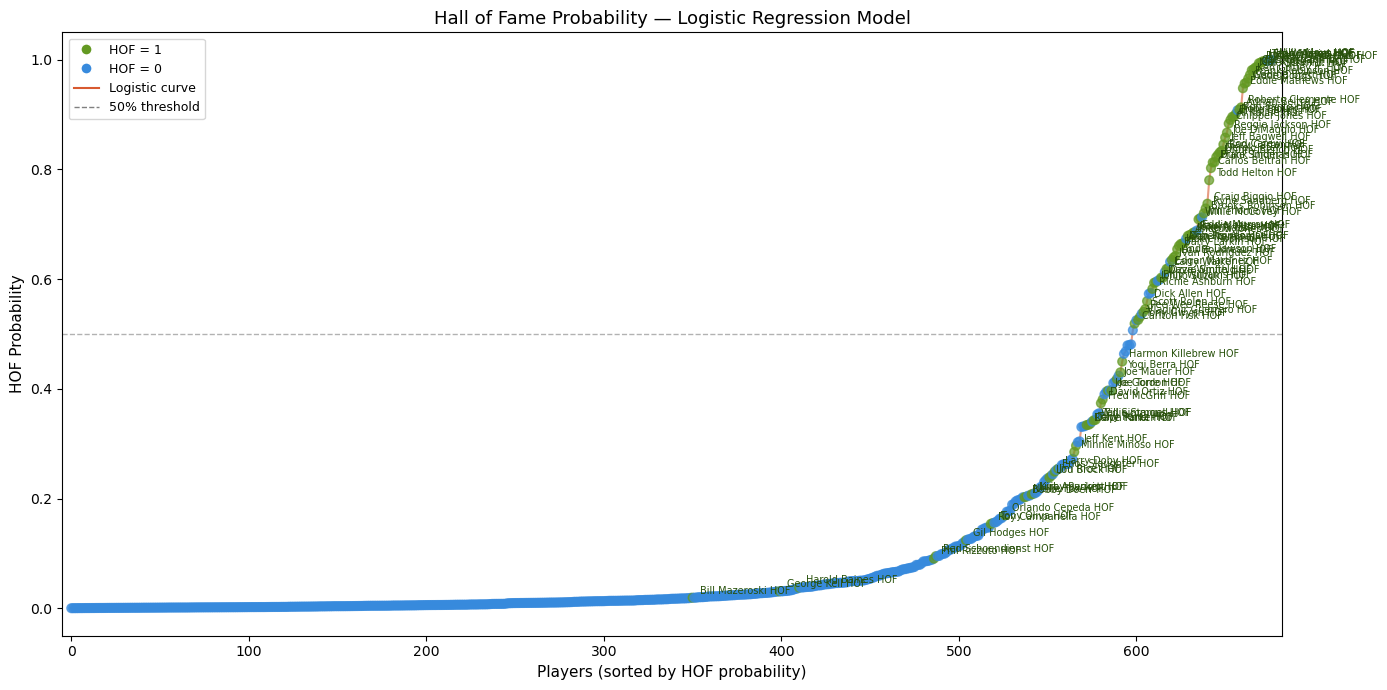

Saved.
                  Player HOF Probability Inducted
1            Barry Bonds          100.0%       No
2        Willie Mays HOF          100.0%      Yes
3         Alex Rodriguez           99.8%       No
4        Stan Musial HOF           99.8%      Yes
5       Ted Williams HOF           99.8%      Yes
6        Henry Aaron HOF           99.7%      Yes
7      Mickey Mantle HOF           99.5%      Yes
8   Rickey Henderson HOF           99.4%      Yes
9         Joe Morgan HOF           98.7%      Yes
10  Carl Yastrzemski HOF           98.6%      Yes
11    Cal Ripken Jr. HOF           98.3%      Yes
12      Mike Schmidt HOF           98.1%      Yes
13   Ken Griffey Jr. HOF           97.3%      Yes
14    Frank Robinson HOF           96.6%      Yes
15      George Brett HOF           95.9%      Yes
16        Wade Boggs HOF           95.7%      Yes
17     Eddie Mathews HOF           94.8%      Yes
18  Roberto Clemente HOF           91.3%      Yes
19     Adrian Beltré HOF           90.9%   

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get predicted HOF probability for every player in df
df['hof_prob'] = model.predict_proba(X)[:, 1]

# Sort by probability for a cleaner plot
df_sorted = df.sort_values('hof_prob').reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Color dots by actual HOF status
colors = df_sorted['hof'].map({0: '#378ADD', 1: '#639922'})
ax.scatter(range(len(df_sorted)), df_sorted['hof_prob'], 
           c=colors, alpha=0.7, zorder=3, s=40)

# Logistic curve overlay — sorted probabilities IS the logistic line
ax.plot(range(len(df_sorted)), df_sorted['hof_prob'], 
        color='#D85A30', linewidth=1.5, alpha=0.6, zorder=2)

# 50% threshold line
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)

# Label every actual HOFer by name
for idx, row in df_sorted.iterrows():
    if row['hof'] == 1:
        ax.annotate(row['name'], 
                    xy=(idx, row['hof_prob']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7, color='#27500A')

# Formatting
ax.set_xlabel('Players (sorted by HOF probability)', fontsize=11)
ax.set_ylabel('HOF Probability', fontsize=11)
ax.set_title('Hall of Fame Probability — Logistic Regression Model', fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-5, len(df_sorted) + 5)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#639922', markersize=8, label='HOF = 1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#378ADD', markersize=8, label='HOF = 0'),
    Line2D([0], [0], color='#D85A30', linewidth=1.5, label='Logistic curve'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='50% threshold')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('h_probability_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")



df_table = df[['name', 'hof_prob', 'hof']].copy()

# Sort numerically FIRST while it's still a float
df_table = df_table.sort_values('hof_prob', ascending=False).reset_index(drop=True)
df_table.index += 1

# THEN convert to string with % sign
df_table['hof_prob'] = (df_table['hof_prob'] * 100).round(1).astype(str) + '%'
df_table['hof'] = df_table['hof'].map({1: 'Yes', 0: 'No'})
df_table.columns = ['Player', 'HOF Probability', 'Inducted']

df_table.to_csv('h_probabilities.csv')
print(df_table.head(20))

In [4]:
print(f"Intercept: {model.intercept_[0]:.5f}")
print(f"WAR7 coef: {model.coef_[0][0]:.5f}")
print(f"TOB coef: {model.coef_[0][1]:.10f}")
print(f"PosAdjust coef: {model.coef_[0][2]:.10f}")

Intercept: -11.16832
WAR7 coef: 0.17981
TOB coef: 0.0007163199
PosAdjust coef: 0.0735208644


## Results and Interpretation

The coefficients tell you the relative importance of each feature. A positive coefficient means higher values increase HOF probability. The positional adjustment coefficient confirms whether the model learned to reward catchers and middle infielders appropriately.

Players not yet HOF eligible who score highly represent the strongest statistical HOF cases from the current era. Players who score low but are already inducted represent cases where the model's statistical features don't fully capture the factors voters weighed — often historical significance, award timing, or era context.

Best threshold for max precision: 0.720
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       115
           1       1.00      0.38      0.55        21

    accuracy                           0.90       136
   macro avg       0.95      0.69      0.75       136
weighted avg       0.91      0.90      0.89       136



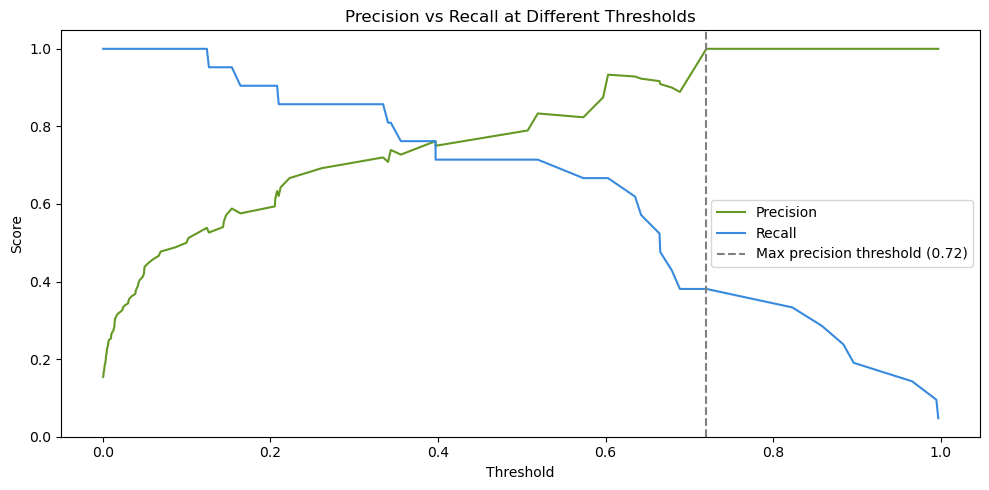

In [5]:
from sklearn.metrics import precision_recall_curve

y_prob = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold that gives maximum precision while still catching at least 1 HOFer
best_threshold = thresholds[precision[:-1].argmax()]
print(f"Best threshold for max precision: {best_threshold:.3f}")

# See what the classification report looks like at that threshold
y_pred_strict = (y_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_strict))
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label='Precision', color='#639922')
plt.plot(thresholds, recall[:-1], label='Recall', color='#378ADD')
plt.axvline(best_threshold, color='gray', linestyle='--', label=f'Max precision threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.tight_layout()
plt.show()